# Machine Learning Lab – Logistic Regression Exercise 3

## Online Retail Customer Purchase Prediction

### Objective
To predict which product a particular customer is most likely to buy using the given online retailer dataset.

### Algorithm Used
Multinomial Logistic Regression

### Problem Type
Supervised Learning – Multiclass Classification

### Target Variable
Customer Purchase Behaviour

### Input Features
- Gender
- Age
- Time spent in the online shop

### Steps
1. Load the required libraries.
2. Load the given online retailer dataset.
3. Explore the dataset.
4. Check for missing values.
5. Encode categorical variables.
6. Prepare the input features and target variable.
7. Split the data into training and testing sets.
8. Train the Logistic Regression model.
9. Predict customer purchase behaviour.
10. Evaluate the model using classification metrics.
11. Visualize the confusion matrix.
12. Summarize the results.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Create the online retailer dataset from the given example

data = pd.DataFrame({
    "Purchase_Behaviour": [
        "Buy now",
        "Buy now",
        "Buy now",
        "Buy now",
        "Buy later",
        "Buy later",
        "Buy later",
        "Buy later",
        "Don't buy",
        "Don't buy",
        "Don't buy",
        "Don't buy"
    ],
    "Gender": [
        "female",
        "female",
        "male",
        "male",
        "female",
        "female",
        "male",
        "male",
        "female",
        "female",
        "male",
        "male"
    ],
    "Age": [
        22, 25, 18, 45,
        27, 27, 48, 34,
        27, 34, 55, 65
    ],
    "Time_Spent": [
        40, 78, 65, 28,
        28, 15, 110, 28,
        5, 10, 56, 80
    ]
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)

data

Dataset created successfully!
Dataset shape: (12, 4)


,Purchase_Behaviour,Gender,Age,Time_Spent
0,Buy now,female,22,40
1,Buy now,female,25,78
2,Buy now,male,18,65
3,Buy now,male,45,28
4,Buy later,female,27,28
5,Buy later,female,27,15
6,Buy later,male,48,110
7,Buy later,male,34,28
8,Don't buy,female,27,5
9,Don't buy,female,34,10


In [4]:
# Explore the dataset

print("Dataset Information:")
data.info()

print("\nStatistical Summary:")
print(data.describe(include="all"))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Purchase_Behaviour  12 non-null     object
 1   Gender              12 non-null     object
 2   Age                 12 non-null     int64 
 3   Time_Spent          12 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 516.0+ bytes

Statistical Summary:
       Purchase_Behaviour  Gender        Age  Time_Spent
count                  12      12  12.000000    12.00000
unique                  3       2        NaN         NaN
top               Buy now  female        NaN         NaN
freq                    4       6        NaN         NaN
mean                  NaN     NaN  35.583333    45.25000
std                   NaN     NaN  14.513056    32.58032
min                   NaN     NaN  18.000000     5.00000
25%                   NaN     NaN  26.500000    24.75000

In [5]:
# Check for missing values

print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Purchase_Behaviour    0
Gender                0
Age                   0
Time_Spent            0
dtype: int64


In [6]:
# Encode categorical variables

gender_encoder = LabelEncoder()
target_encoder = LabelEncoder()

data["Gender_Encoded"] = gender_encoder.fit_transform(data["Gender"])
data["Target_Encoded"] = target_encoder.fit_transform(data["Purchase_Behaviour"])

print("Gender encoding:")
for label, value in zip(
    gender_encoder.classes_,
    gender_encoder.transform(gender_encoder.classes_)
):
    print(label, "->", value)

print("\nPurchase behaviour encoding:")
for label, value in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(label, "->", value)

Gender encoding:
female -> 0
male -> 1

Purchase behaviour encoding:
Buy later -> 0
Buy now -> 1
Don't buy -> 2


In [7]:
# Prepare input features and target variable

feature_cols = [
    "Gender_Encoded",
    "Age",
    "Time_Spent"
]

X = data[feature_cols]
y = data["Target_Encoded"]

print("Selected features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['Gender_Encoded', 'Age', 'Time_Spent']

Feature shape: (12, 3)
Target shape: (12,)


In [8]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (9, 3)
Testing feature shape: (3, 3)
Training target shape: (9,)
Testing target shape: (3,)


In [9]:
# Train the Multinomial Logistic Regression model

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

model.fit(X_train, y_train)

print("Multinomial Logistic Regression model trained successfully!")

Multinomial Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)

Predictions generated successfully!
Actual values:    [2 1 0]
Predicted values: [2 1 1]


In [11]:
# Evaluate the Multinomial Logistic Regression model

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
)

print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Model Accuracy: 0.6666666666666666

Confusion Matrix:
[[0 1 0]
 [0 1 0]
 [0 0 1]]

Classification Report:
              precision    recall  f1-score   support

   Buy later       0.00      0.00      0.00         1
     Buy now       0.50      1.00      0.67         1
   Don't buy       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



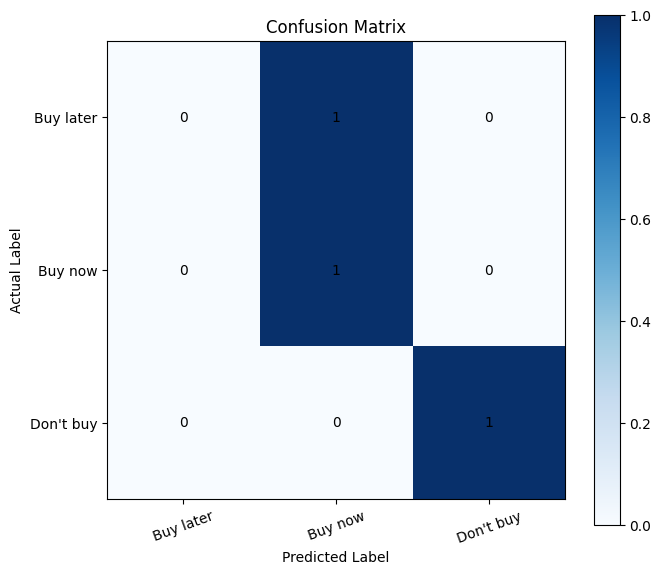

In [12]:
# Visualize the confusion matrix

plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(len(target_encoder.classes_)),
    target_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(target_encoder.classes_)),
    target_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Result Summary

The Multinomial Logistic Regression model was trained to predict customer purchase behaviour using gender, age, and time spent in the online shop.

### Performance Results

| Metric | Value |
|---|---:|
| Accuracy | 66.67% |
| Test Samples | 3 |

### Confusion Matrix

The confusion matrix shows the predictions made for the three purchase-behaviour classes:

- Buy later
- Buy now
- Don't buy

The model correctly classified 2 out of 3 test samples.

## Conclusion

The Multinomial Logistic Regression model was successfully implemented to predict customer purchase behaviour using gender, age, and time spent in the online shop.

The model achieved an accuracy of 66.67% on the test dataset and correctly classified 2 out of the 3 test samples.

The confusion matrix was used to examine the predictions for the three purchase-behaviour classes: Buy later, Buy now, and Don't buy.

Thus, the experiment demonstrates the application of Multinomial Logistic Regression for multiclass customer purchase behaviour classification.